# Checkpoint 5 – Analiza podataka uz OLAP alat

## 1. Odabir OLAP alata

Za provedbu OLAP analize odabran je alat Power BI.

## 2. Učitavanje podataka u Power BI i provjera modela

![Model odnosa u Power BI-ju](powerbi_model_view.png)

## 3. Definiranje osnovnih mjera

Mjere:

- `Ukupan broj transakcija`
- `Ukupan iznos transakcija`
- `Prosječan iznos transakcije`
- `Broj prijevarnih transakcija`
- `Udio prijevara`

Za izradu mjera -> DAX formule u Power BI-ju:

```DAX
Ukupan broj transakcija = COUNTROWS('bank_fraud_dw fact_bank_transaction')

Ukupan iznos transakcija = SUM('bank_fraud_dw fact_bank_transaction'[transaction_amount])

Prosječan iznos transakcije = AVERAGE('bank_fraud_dw fact_bank_transaction'[transaction_amount])

Broj prijevarnih transakcija = CALCULATE(
    COUNTROWS('bank_fraud_dw fact_bank_transaction'),
    'bank_fraud_dw fact_bank_transaction'[is_fraud] = TRUE()
)

Udio prijevara = DIVIDE(
    [Broj prijevarnih transakcija],
    [Ukupan broj transakcija],
    0
)

## 4. Dashboard: Pregled transakcija

In [18]:
import pandas as pd
from sqlalchemy import create_engine, text

MYSQL_USER = "root"
MYSQL_PASSWORD = "root"
MYSQL_HOST = "localhost"
MYSQL_PORT = "3306"
DW_DB = "bank_fraud_dw"

dw_connection_string = (
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@"
    f"{MYSQL_HOST}:{MYSQL_PORT}/{DW_DB}"
)

dw_engine = create_engine(dw_connection_string)

print("Konekcija na bank_fraud_dw je pripremljena.")

Konekcija na bank_fraud_dw je pripremljena.


In [20]:
daily_transaction_check = pd.read_sql(
    """
    SELECT
        d.full_date,
        COUNT(*) AS transaction_count
    FROM fact_bank_transaction f
    JOIN dim_date d
        ON f.date_tk = d.date_tk
    GROUP BY d.full_date
    ORDER BY d.full_date;
    """,
    dw_engine
)

display(daily_transaction_check)

print("Ukupan broj dana u dim_date korištenih u fact tablici:", len(daily_transaction_check))
print("Ukupan broj transakcija:", daily_transaction_check["transaction_count"].sum())

display(daily_transaction_check.tail())

,full_date,transaction_count
0,2025-01-01,6656
1,2025-01-02,6778
2,2025-01-03,6751
3,2025-01-04,6670
4,2025-01-05,6630
5,2025-01-06,6629
6,2025-01-07,6640
7,2025-01-08,6527
8,2025-01-09,6715
9,2025-01-10,6537


Ukupan broj dana u dim_date korištenih u fact tablici: 31
Ukupan broj transakcija: 200000


,full_date,transaction_count
26,2025-01-27,6523
27,2025-01-28,6602
28,2025-01-29,6854
29,2025-01-30,6825
30,2025-01-31,1


In [22]:
jan_31_transaction = pd.read_sql(
    """
    SELECT
        f.transaction_id,
        f.transaction_code,
        d.full_date,
        f.transaction_time,
        f.transaction_amount,
        f.account_balance,
        f.is_fraud,
        f.transaction_description
    FROM fact_bank_transaction f
    JOIN dim_date d
        ON f.date_tk = d.date_tk
    WHERE d.full_date = '2025-01-31';
    """,
    dw_engine
)

display(jan_31_transaction)

,transaction_id,transaction_code,full_date,transaction_time,transaction_amount,account_balance,is_fraud,transaction_description
0,188457,0fbe7b8d-62f9-42fb-8e18-a2634ff62d71,2025-01-31,0 days 16:10:11,11686.22,94481.89,0,Online gaming


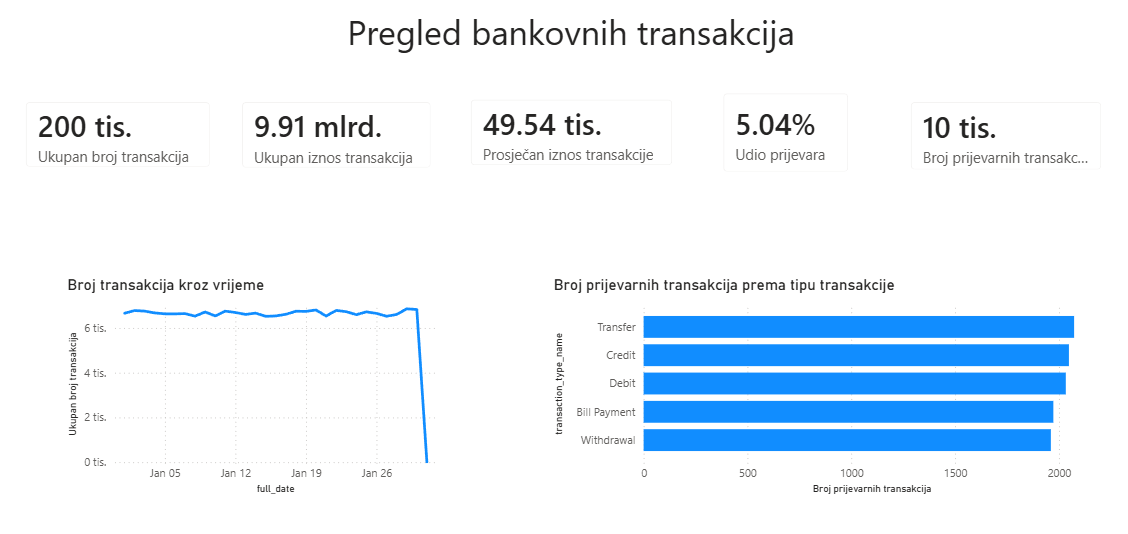

## 5. Analiza prijevarnih transakcija

![Analiza prijevara u Power BI-ju](powerbi_analiza_prijevara.png)

## 6. OLAP operacije na kocki

Operacije slice, dice, pivot, drill-down i roll-up

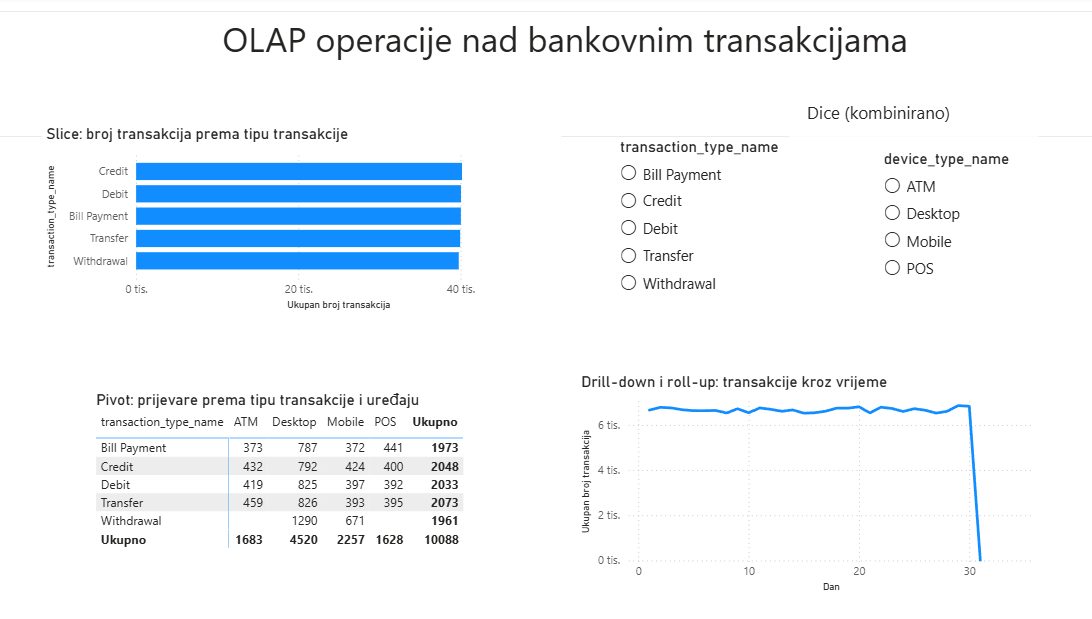

### 6.1. Slice operacija

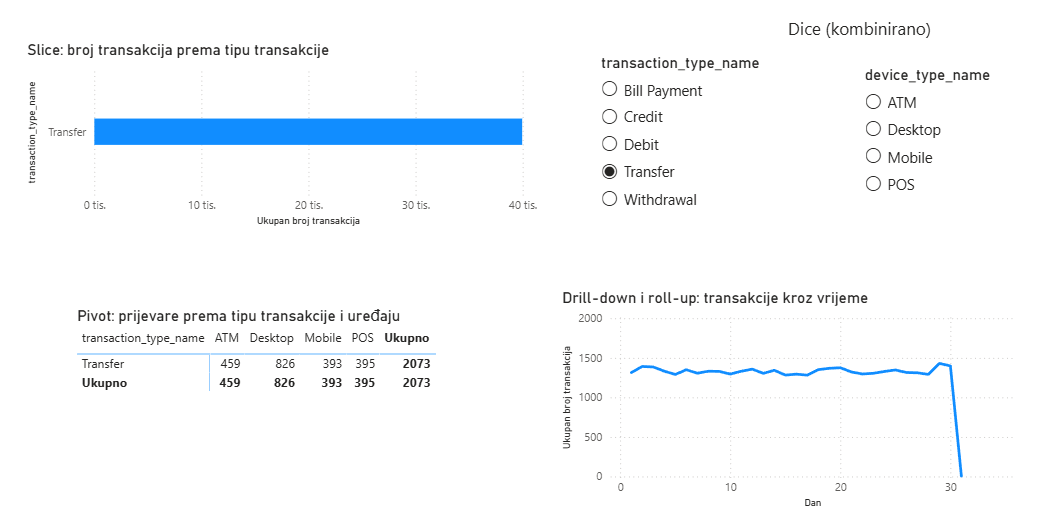

### 6.2. Dice operacija

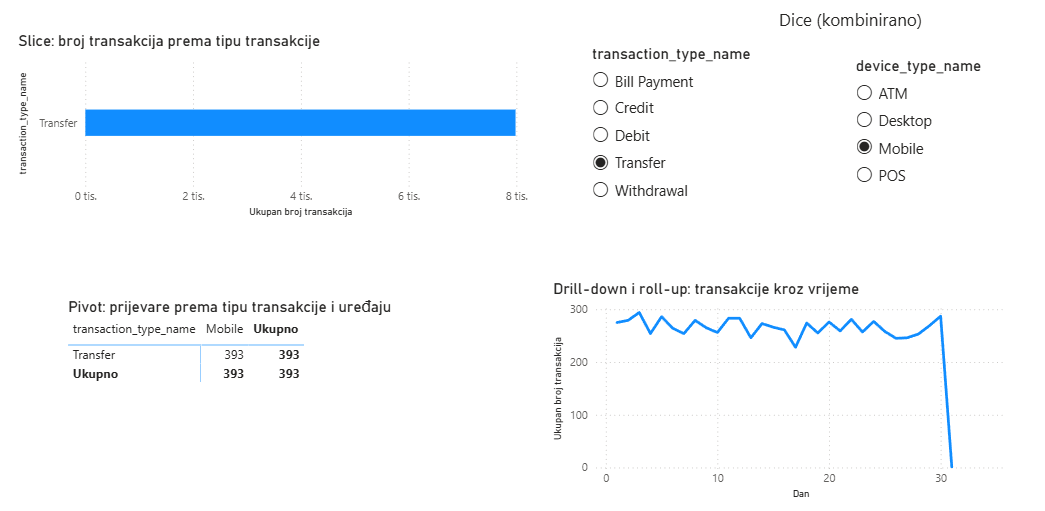

### 6.3. Pivot operacija

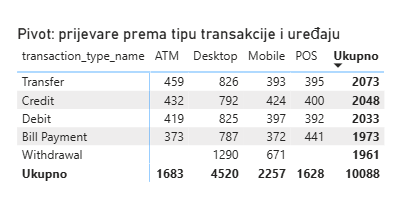

### 6.4. Drill-down operacija

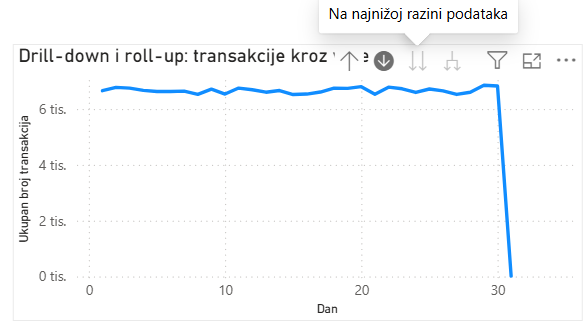

### 6.5. Roll-up operacija

![Roll-up operacija - godišnja razina](powerbi_olap_rollup_godina.png)